

# Mutual Fund Industry Analysis
## Exploratory Data Analysis (EDA)
### Data Analyst Internship – Day 3

#**Prepared by:** Your Name  
#**Tools Used:** Python, Pandas, Matplotlib, Seaborn  
#**Dataset:** Mutual Fund Industry Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [65]:
import os
os.getcwd()

'C:\\Users\\User\\Desktop\\Mutual_Fund_Analytics 2'

In [66]:
os.listdir()

['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'aum_growth.png',
 'bluestock_mf.db',
 'charts',
 'chart_name.png',
 'data',
 'data_dictionary.md',
 'dhasbord',
 'EDA_Analysis.ipynb',
 'heatmap.png',
 'nav_trend.png',
 'notebook',
 'README.md',
 'reports',
 'requirements.txt',
 'sip_inflow_trend.png',
 'sip_trend.png',
 'sql']

In [67]:
import os
os.listdir("data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Bluestock_MF_Capstone_Project (1).pdf',
 'Bluestock_MF_Capstone_Project.pdf',
 'live_nav_125497.csv']

In [68]:
import os
os.listdir("data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Bluestock_MF_Capstone_Project (1).pdf',
 'Bluestock_MF_Capstone_Project.pdf',
 'live_nav_125497.csv']

In [69]:
import pandas as pd

nav = pd.read_csv("data/raw/02_nav_history.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/05_category_inflows.csv")
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
investor = pd.read_csv("data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

In [70]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [71]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [72]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [73]:
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)
print(investor.shape)
print(portfolio.shape)

(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(32778, 13)
(322, 8)


In [74]:
print(nav.columns)
print(aum.columns)
print(sip.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


In [75]:
nav.columns

aum.columns

sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [76]:
sip['month'] = pd.to_datetime(sip['month'])

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

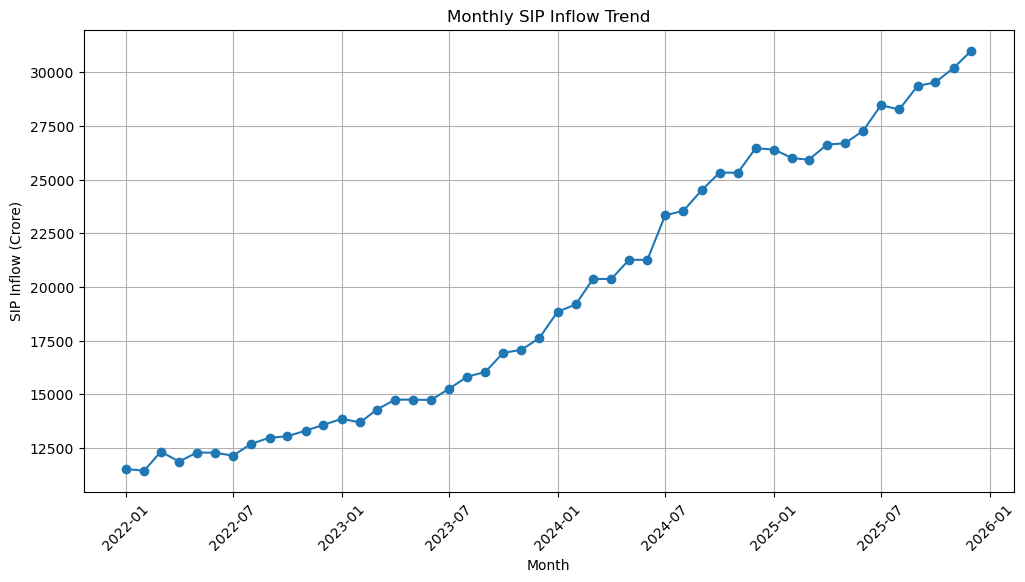

In [78]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()


In [79]:
plt.savefig("sip_inflow_trend.png")

<Figure size 640x480 with 0 Axes>

In [80]:
print(nav.columns)
print(aum.columns)
print(folio.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


In [81]:

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [82]:
nav['date'] = pd.to_datetime(nav['date'])

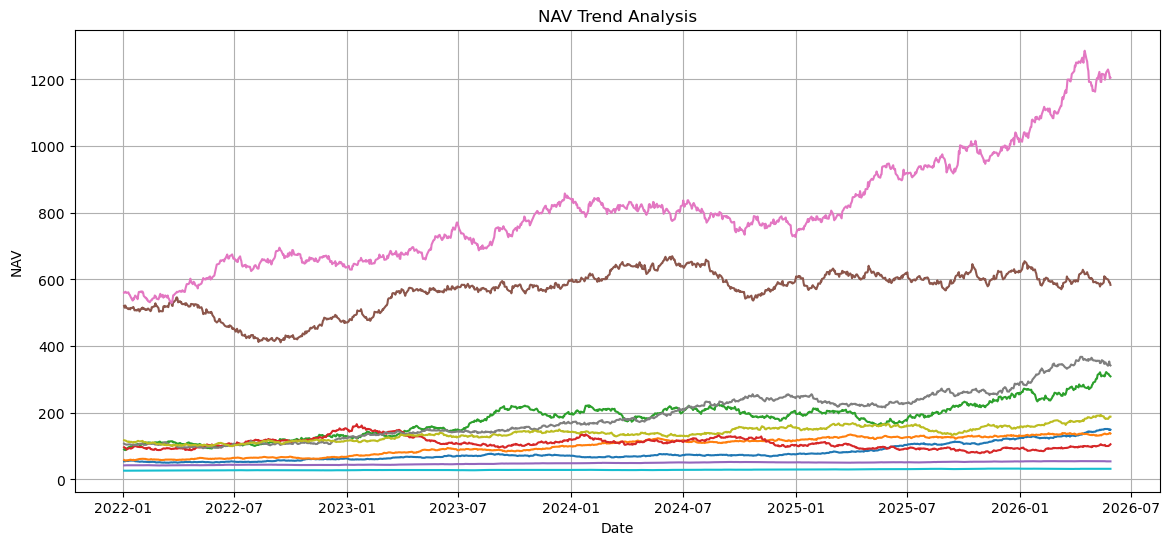

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for code in nav['amfi_code'].unique()[:10]:
    temp = nav[nav['amfi_code'] == code]
    plt.plot(temp['date'], temp['nav'])

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.show()

In [84]:
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

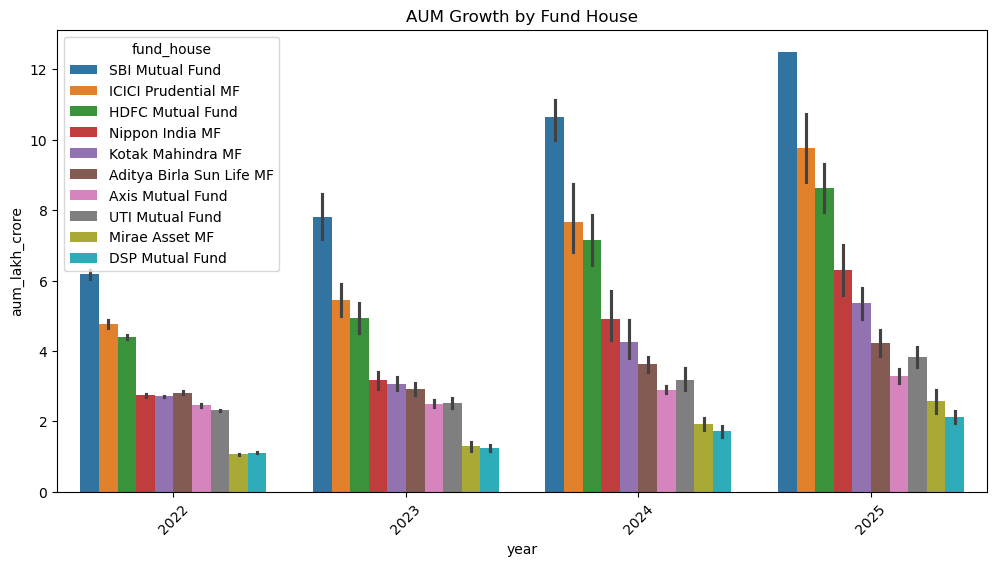

In [85]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

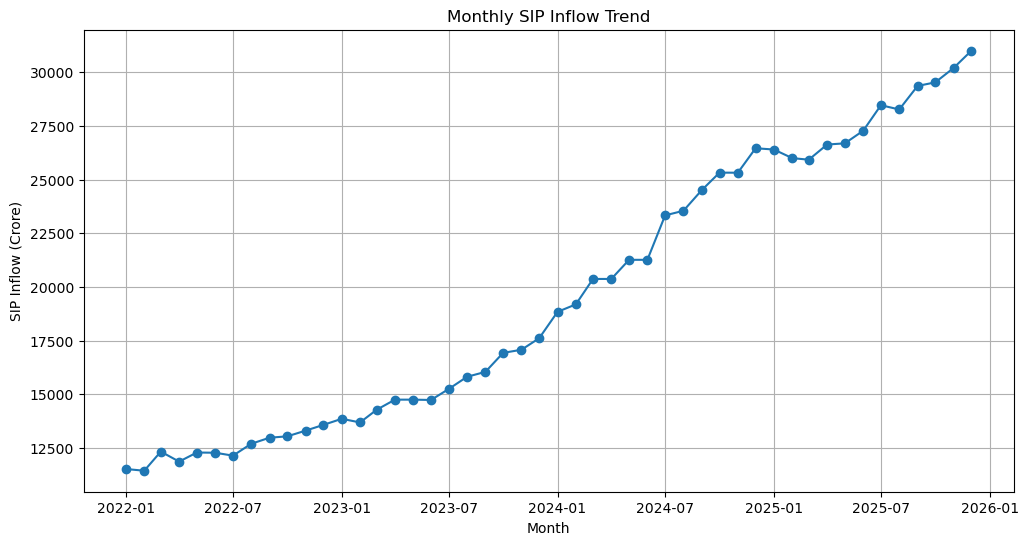

In [86]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

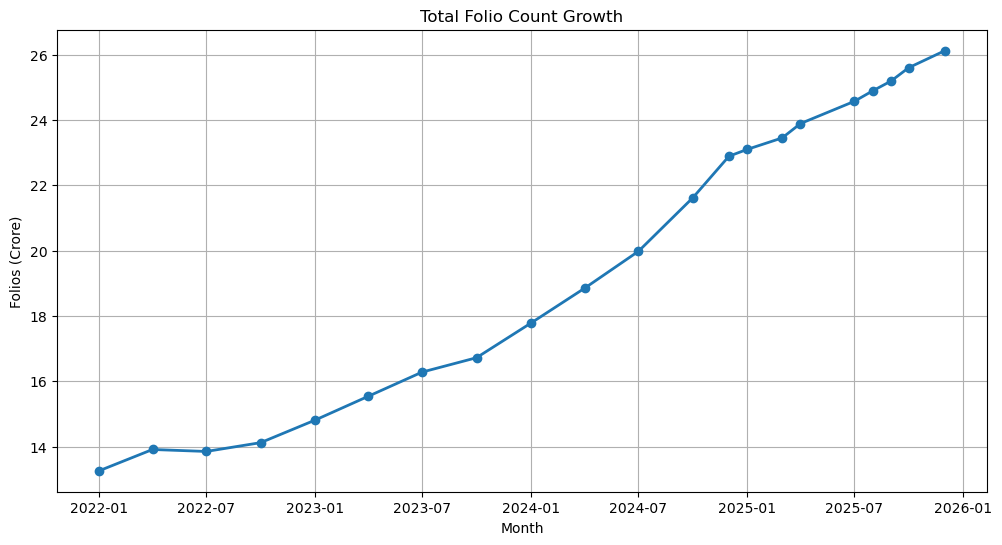

In [87]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o',
    linewidth=2
)

plt.title("Total Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)

plt.show()

In [88]:
plt.savefig("nav_trend.png")

<Figure size 640x480 with 0 Axes>

In [89]:
plt.savefig("aum_growth.png")

<Figure size 640x480 with 0 Axes>

In [90]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [91]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

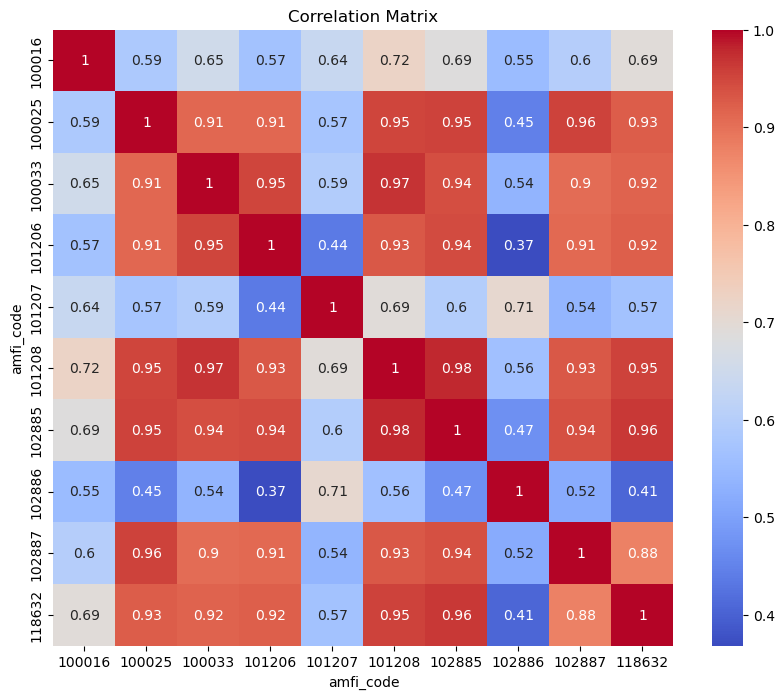

In [92]:
nav_pivot = nav.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

corr = nav_pivot.iloc[:, :10].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [93]:
plt.savefig("chart_name.png")

<Figure size 640x480 with 0 Axes>

In [94]:
import os
os.makedirs("charts", exist_ok=True)

In [95]:
plt.savefig("charts/nav_trend.png")

<Figure size 640x480 with 0 Axes>

In [96]:
category.columns

investor.columns

portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [97]:
portfolio['sector'].value_counts()

sector
Banking           60
IT                40
Pharma            38
Automobile        33
Utilities         24
Infrastructure    22
FMCG              21
Telecom           15
Diversified       14
Energy            13
Cement            12
NBFC              11
Paints            10
Consumer Goods     9
Name: count, dtype: int64

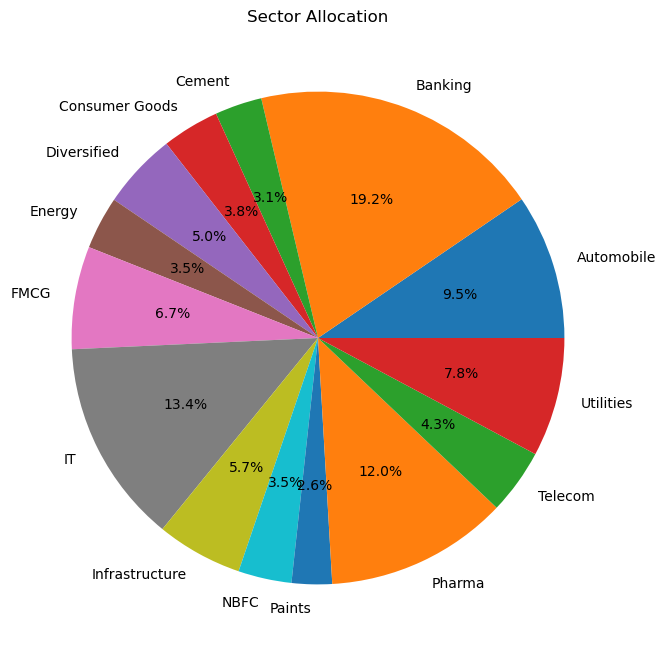

In [98]:
sector_data = portfolio.groupby('sector')['weight_pct'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%'
)

plt.title("Sector Allocation")
plt.show()

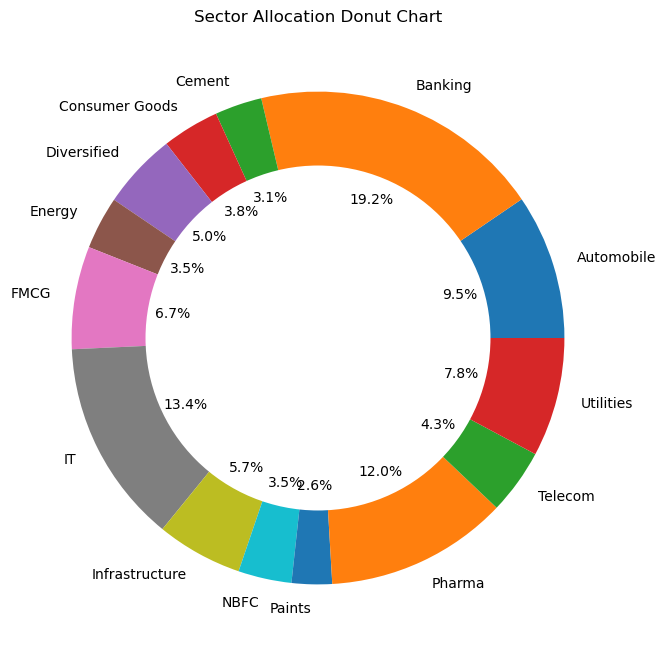

In [99]:
fig, ax = plt.subplots(figsize=(8,8))

ax.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Donut Chart")
plt.show()

In [100]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [101]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [102]:
investor.columns
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [103]:
heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

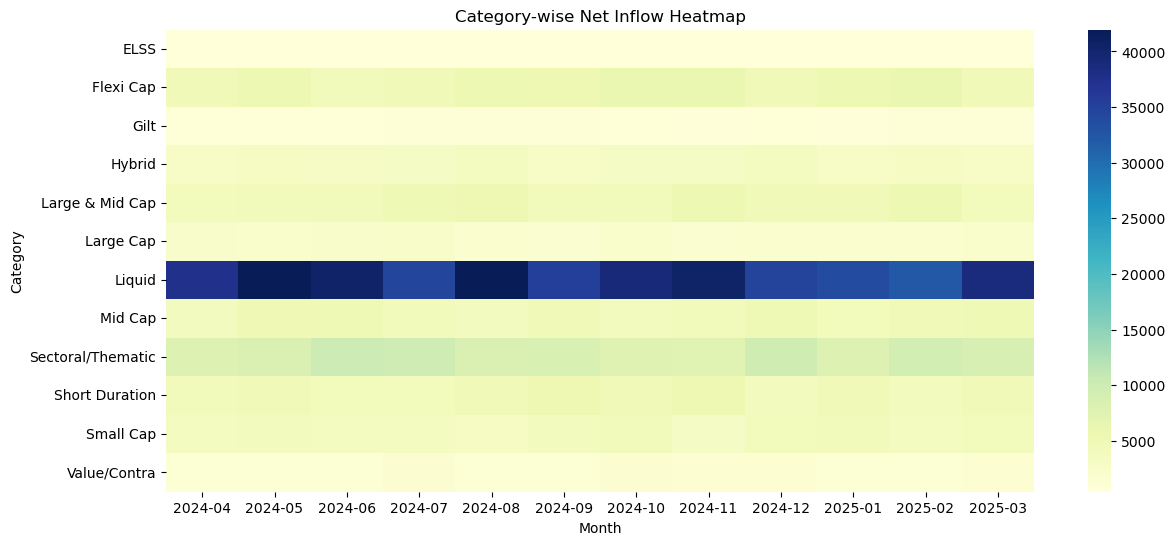

In [104]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

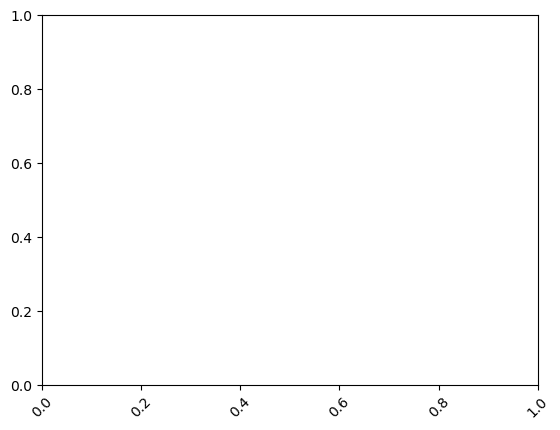

In [105]:
plt.xticks(rotation=45)

In [106]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

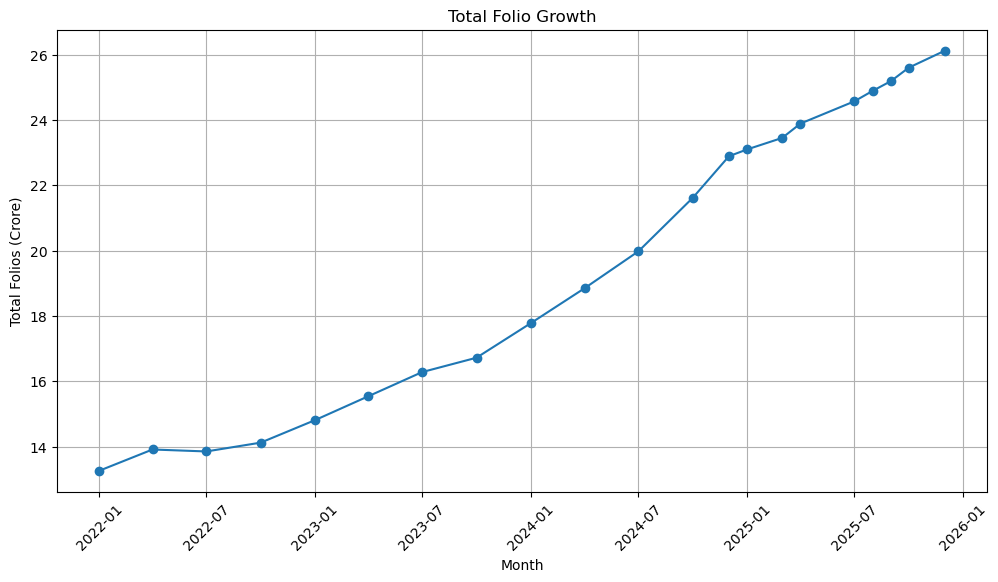

In [107]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title("Total Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

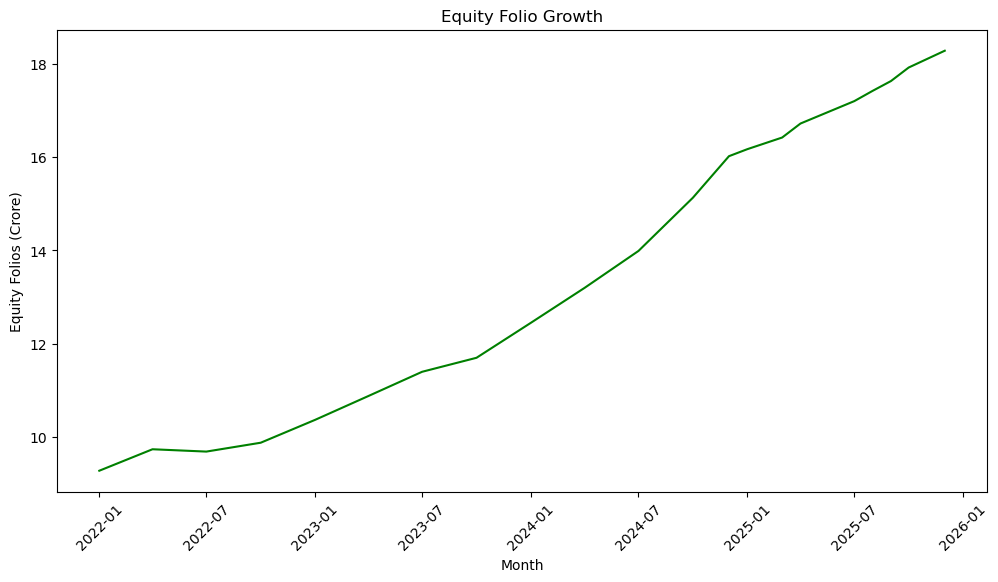

In [108]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['equity_folios_crore'],
    color='green'
)

plt.title("Equity Folio Growth")
plt.xlabel("Month")
plt.ylabel("Equity Folios (Crore)")
plt.xticks(rotation=45)

plt.show()

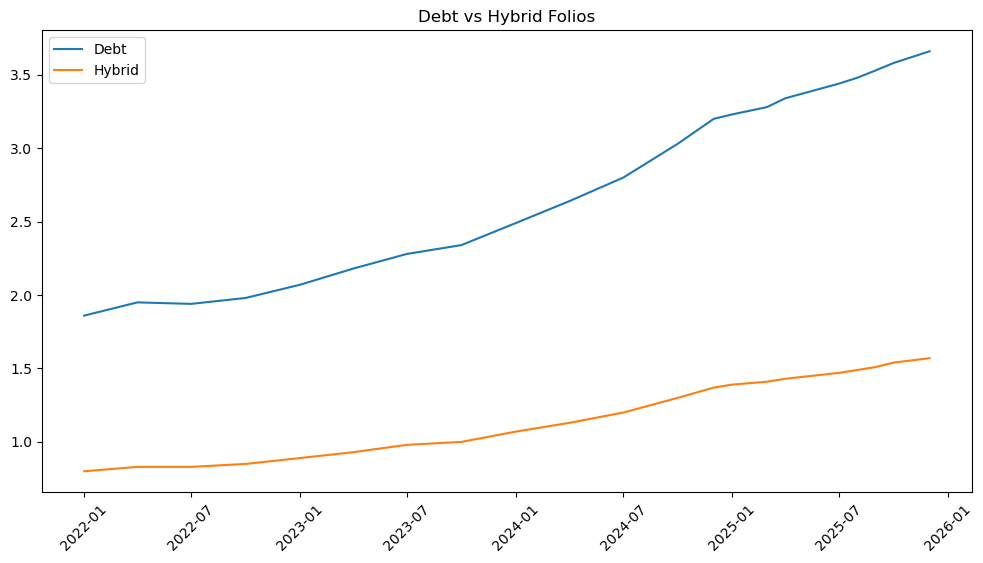

In [109]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['debt_folios_crore'],
    label='Debt'
)

plt.plot(
    folio['month'],
    folio['hybrid_folios_crore'],
    label='Hybrid'
)

plt.legend()
plt.title("Debt vs Hybrid Folios")
plt.xticks(rotation=45)

plt.show()

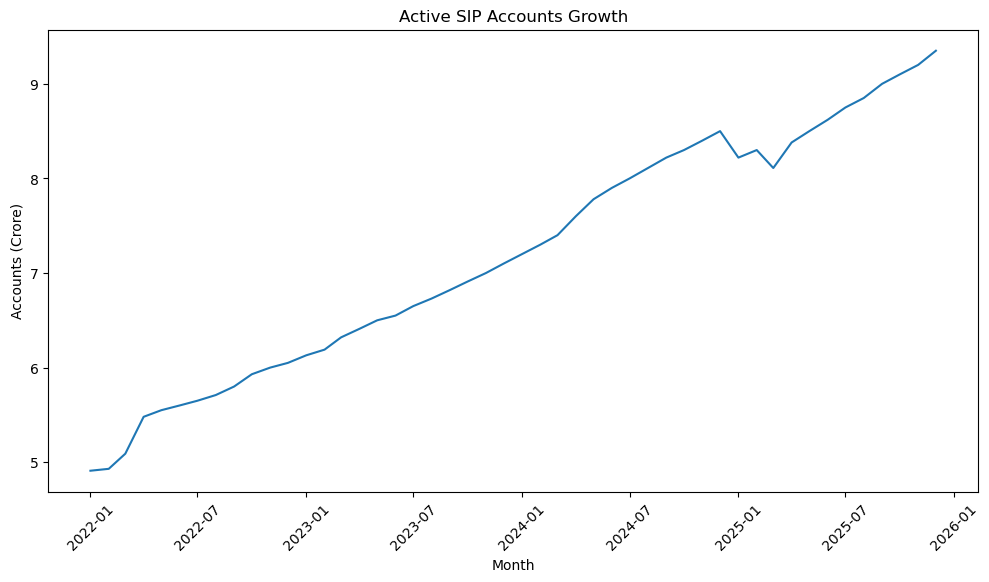

In [110]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['active_sip_accounts_crore']
)

plt.title("Active SIP Accounts Growth")
plt.xlabel("Month")
plt.ylabel("Accounts (Crore)")
plt.xticks(rotation=45)

plt.show()

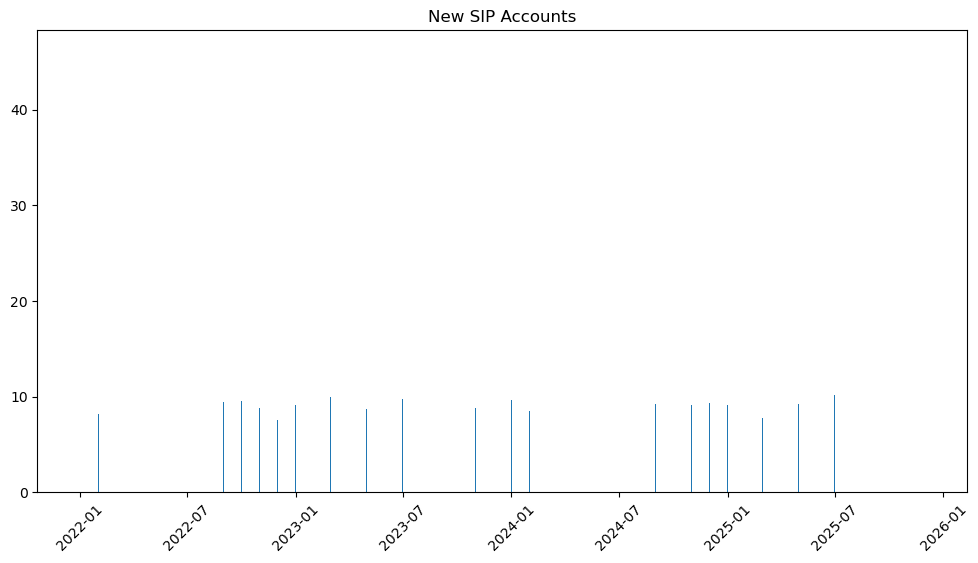

In [111]:
plt.figure(figsize=(12,6))

plt.bar(
    sip['month'],
    sip['new_sip_accounts_lakh']
)

plt.title("New SIP Accounts")
plt.xticks(rotation=45)

plt.show()

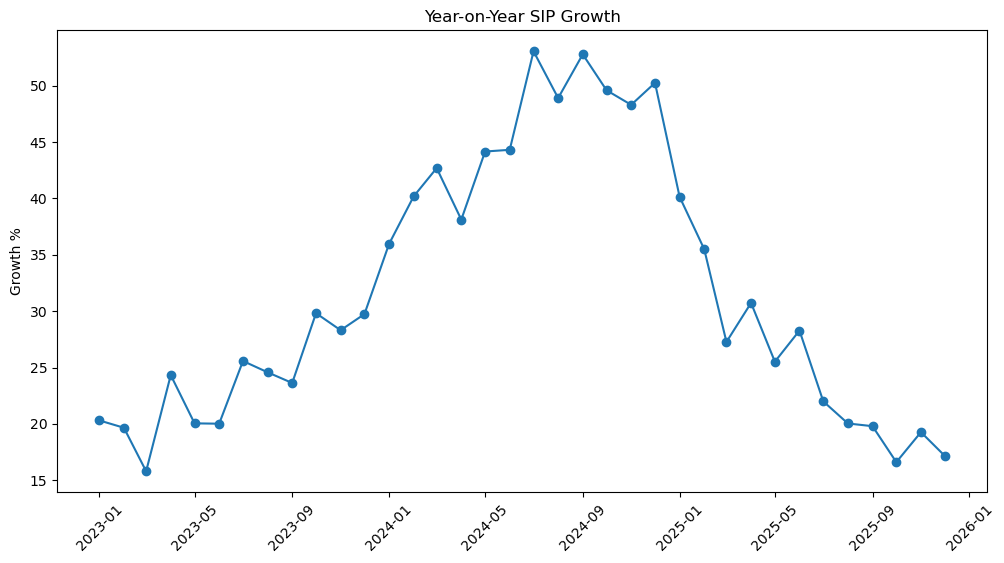

In [112]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['yoy_growth_pct'],
    marker='o'
)

plt.title("Year-on-Year SIP Growth")
plt.ylabel("Growth %")
plt.xticks(rotation=45)

plt.show()

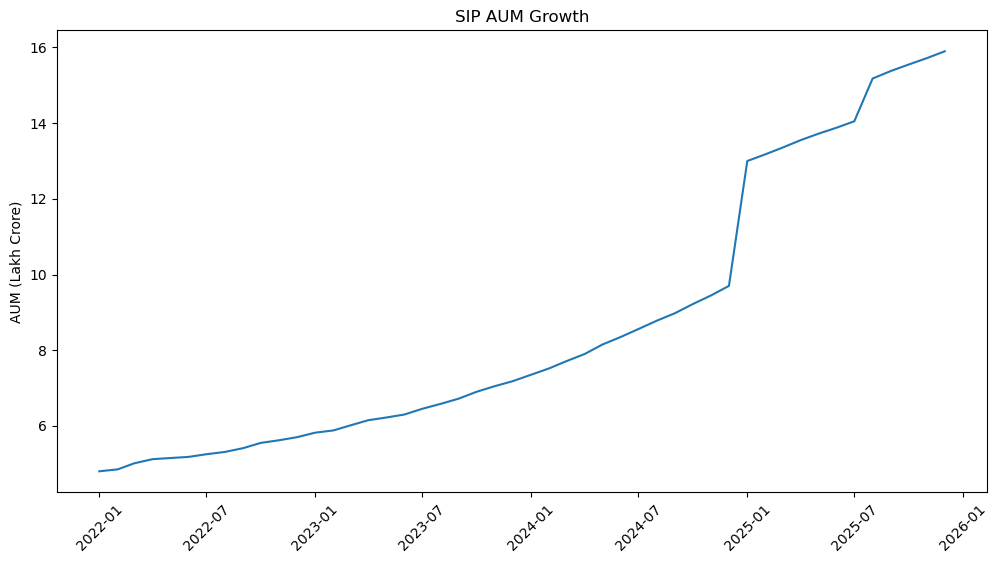

In [113]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_aum_lakh_crore']
)

plt.title("SIP AUM Growth")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.show()

# EDA Findings

1. SIP inflows increased steadily from 2022 to 2025.
2. Total folio count showed strong growth.
3. Equity folios dominate the industry.
4. SIP accounts increased consistently.
5. Certain fund categories attracted higher inflows.
6. AUM growth indicates industry expansion.
7. Sector allocation is concentrated in a few sectors.
8. NAV trends show long-term growth.
9. SIP AUM reached record levels.
10. Mutual fund participation increased significantly.

# Mutual Fund Industry EDA Analysis
## Day 3 – Exploratory Data Analysis
### Data Analyst Internship Project


In [114]:
plt.savefig("nav_trend.png")

<Figure size 640x480 with 0 Axes>

In [115]:
plt.savefig("sip_trend.png")
plt.savefig("aum_growth.png")
plt.savefig("heatmap.png")

<Figure size 640x480 with 0 Axes>

In [116]:
import os
os.makedirs("charts", exist_ok=True)

In [117]:
plt.savefig("charts/nav_trend.png")

<Figure size 640x480 with 0 Axes>

# Dataset Overview

This analysis uses the following datasets:

- NAV History
- AUM by Fund House
- Monthly SIP Inflows
- Category Inflows
- Industry Folio Count
- Portfolio Holdings

The objective is to identify trends, growth patterns, and investment insights in the Indian mutual fund industry.

In [118]:
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
AUM: (90, 6)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Portfolio: (322, 8)


In [119]:
print(nav.isnull().sum())
print(aum.isnull().sum())
print(sip.isnull().sum())

amfi_code    0
date         0
nav          0
dtype: int64
date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
year              0
dtype: int64
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64


# EDA Findings

1. SIP inflows increased steadily from 2022 to 2025.
2. Total folio count showed significant growth.
3. Equity folios dominate the industry.
4. AUM increased across major fund houses.
5. Active SIP accounts grew consistently.
6. Some sectors received higher portfolio allocations.
7. NAV trends indicate long-term growth.
8. Category inflows vary across months.
9. Industry participation increased significantly.
10. Mutual fund assets expanded strongly.

# Conclusion

The mutual fund industry experienced strong growth between 2022 and 2025. SIP participation, folio counts, and assets under management increased steadily, indicating growing investor confidence and industry expansion.

In [120]:
import os
os.makedirs("charts", exist_ok=True)

In [121]:
import os
os.listdir()

['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'aum_growth.png',
 'bluestock_mf.db',
 'charts',
 'chart_name.png',
 'data',
 'data_dictionary.md',
 'dhasbord',
 'EDA_Analysis.ipynb',
 'heatmap.png',
 'nav_trend.png',
 'notebook',
 'README.md',
 'reports',
 'requirements.txt',
 'sip_inflow_trend.png',
 'sip_trend.png',
 'sql']